# Topic Analysis and Visualization

This notebook visualizes and analyzes the discovered topics from batch inference:
- Topic distribution across all complaints
- Top terms per topic with heatmap
- Sample complaints for each topic
- Topic interpretation and insights

## Setup and Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

## Load Results

In [19]:
# Load the results CSV
results_dir = Path('../data/results')
csv_file = results_dir / 'complaints_with_topics.csv'
summary_file = results_dir / 'topic_summary.txt'

print(f"Loading {csv_file}...")
df = pd.read_csv(csv_file)

print(f"✓ Loaded {len(df):,} complaints")
print(f"\nDataframe shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()[:10]}...") # Show first 10 columns

Loading ../data/results/complaints_with_topics.csv...
✓ Loaded 176,942 complaints

Dataframe shape: (176942, 35)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code']...


## Topic Distribution

In [20]:
# Count topics
topic_counts = df['primary_topic'].value_counts().sort_index()
n_topics = len(topic_counts)

print(f"\nNumber of topics: {n_topics}")
print(f"\nTopic Distribution:")
print(f"{'Topic':<10} {'Count':<10} {'Percentage':<15} {'Distribution'}")
print("=" * 70)

for topic_id, count in topic_counts.items():
    percentage = 100 * count / len(df)
    bar_length = int(percentage / 2)
    bar = '█' * bar_length + '░' * (50 - bar_length)
    print(f"Topic {topic_id:<3} {count:<10,} {percentage:<14.1f}% {bar}")


Number of topics: 15

Topic Distribution:
Topic      Count      Percentage      Distribution
Topic 0   26,527     15.0          % ███████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 1   7,376      4.2           % ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 2   15,709     8.9           % ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 3   11,297     6.4           % ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 4   10,939     6.2           % ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 5   5,466      3.1           % █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 6   11,849     6.7           % ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 7   10,691     6.0           % ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 8   10,019     5.7           % ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 9   13,823     7.8           % ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
Topic 10  7,127      4.0  

## Visualize Topic Distribution

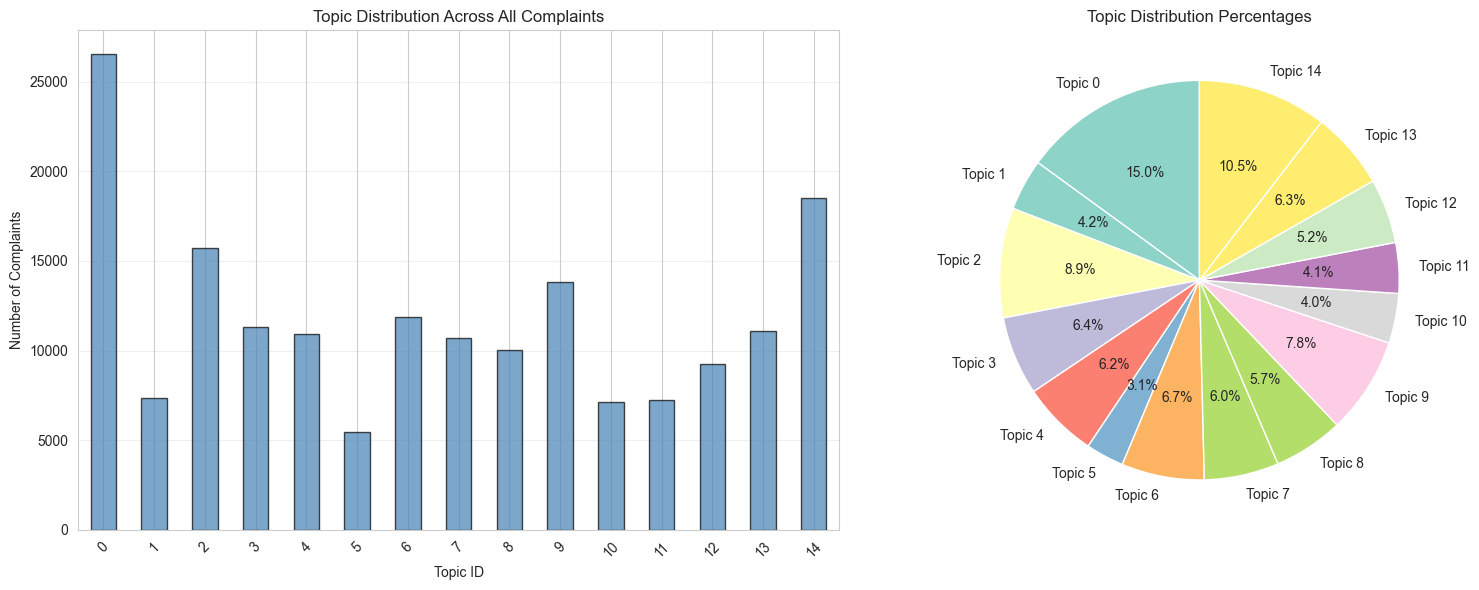

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
topic_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Topic ID')
axes[0].set_ylabel('Number of Complaints')
axes[0].set_title('Topic Distribution Across All Complaints')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
colors = plt.cm.Set3(np.linspace(0, 1, n_topics))
axes[1].pie(topic_counts.values, labels=[f'Topic {i}' for i in topic_counts.index], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Topic Distribution Percentages')

plt.tight_layout()
plt.show()

## Confidence Analysis

In [22]:
# Analyze confidence scores
confidence_stats = df['topic_confidence'].describe()

print(f"\nConfidence Score Statistics:")
print(f"  - Mean:   {confidence_stats['mean']:.4f}")
print(f"  - Median: {df['topic_confidence'].median():.4f}")
print(f"  - Std:    {confidence_stats['std']:.4f}")
print(f"  - Min:    {confidence_stats['min']:.4f}")
print(f"  - Max:    {confidence_stats['max']:.4f}")

# Confidence buckets
high_conf = (df['topic_confidence'] >= 0.7).sum()
med_conf = ((df['topic_confidence'] >= 0.5) & (df['topic_confidence'] < 0.7)).sum()
low_conf = (df['topic_confidence'] < 0.5).sum()

print(f"\nConfidence Distribution:")
print(f"  - High (≥ 0.7): {high_conf:,} ({100*high_conf/len(df):.1f}%)")
print(f"  - Medium (0.5-0.7): {med_conf:,} ({100*med_conf/len(df):.1f}%)")
print(f"  - Low (< 0.5): {low_conf:,} ({100*low_conf/len(df):.1f}%)")


Confidence Score Statistics:
  - Mean:   0.0393
  - Median: 0.0337
  - Std:    0.0219
  - Min:    0.0000
  - Max:    0.1573

Confidence Distribution:
  - High (≥ 0.7): 0 (0.0%)
  - Medium (0.5-0.7): 0 (0.0%)
  - Low (< 0.5): 176,942 (100.0%)


## Visualize Confidence Distribution

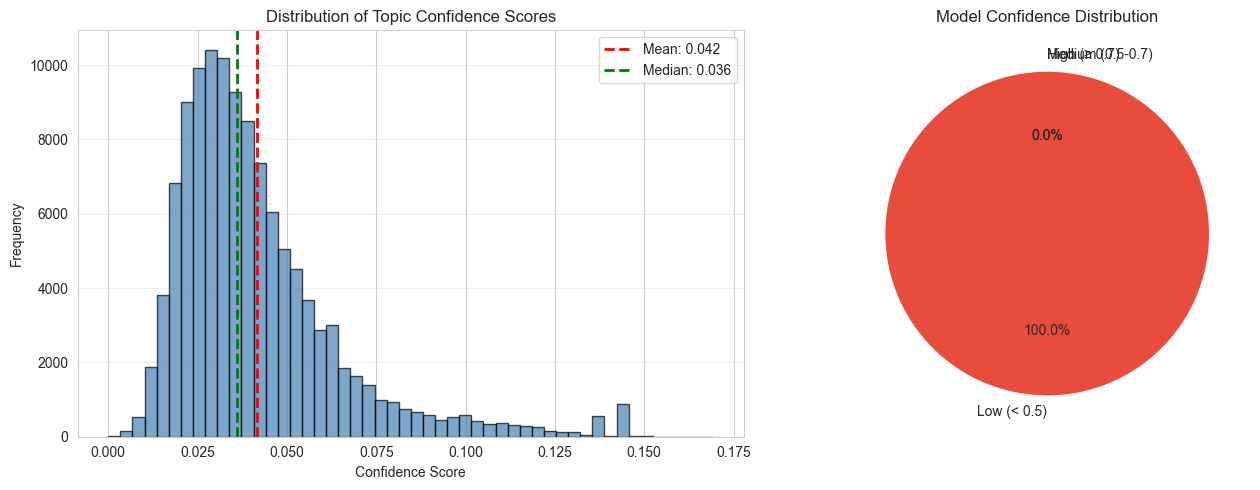

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['topic_confidence'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['topic_confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["topic_confidence"].mean():.3f}')
axes[0].axvline(df['topic_confidence'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["topic_confidence"].median():.3f}')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Topic Confidence Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Confidence bucket pie chart
confidence_buckets = [high_conf, med_conf, low_conf]
confidence_labels = ['High (≥ 0.7)', 'Medium (0.5-0.7)', 'Low (< 0.5)']
colors_conf = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(confidence_buckets, labels=confidence_labels, autopct='%1.1f%%', colors=colors_conf, startangle=90)
axes[1].set_title('Model Confidence Distribution')

plt.tight_layout()
plt.show()

## Show Topic Summary

In [16]:
# Read and display the topic summary
print("\n" + "="*80)
print("TOPIC MODELING RESULTS SUMMARY")
print("="*80 + "\n")

with open(summary_file, 'r') as f:
    content = f.read()
    # Print first 2000 characters (includes top terms)
    print(content[:3000])
    print("\n[... (see topic_summary.txt for complete list) ...]")


TOPIC MODELING RESULTS SUMMARY

TOPIC MODELING INFERENCE SUMMARY

Model Type: NMF
Number of Topics: 15
Documents Analyzed: 117372
Output File: /Users/zhusizhen/Documents/project/data/results/complaints_with_topics.csv

TOPIC DISTRIBUTION:
--------------------------------------------------------------------------------
Topic 0:  18001 ( 15.3%)
Topic 1:   8328 (  7.1%)
Topic 2:   4883 (  4.2%)
Topic 3:   8572 (  7.3%)
Topic 4:   2272 (  1.9%)
Topic 5:  11703 ( 10.0%)
Topic 6:   6679 (  5.7%)
Topic 7:  12311 ( 10.5%)
Topic 8:   5732 (  4.9%)
Topic 9:   8587 (  7.3%)
Topic 10:   7031 (  6.0%)
Topic 11:   5769 (  4.9%)
Topic 12:   8440 (  7.2%)
Topic 13:   2923 (  2.5%)
Topic 14:   6141 (  5.2%)

TOP TERMS PER TOPIC:
--------------------------------------------------------------------------------

Topic 0:
  - xxxx                 (13.4032)
  - xxxxxxxx             (0.6501)
  - date                 (0.2610)
  - number               (0.2497)
  - receive              (0.1885)
  - end        

## Sample Complaints Per Topic

In [17]:
# Show one sample complaint per topic
print("\nSAMPLE COMPLAINTS PER TOPIC")
print("="*100)

text_col = 'Consumer complaint narrative'

for topic_id in sorted(df['primary_topic'].unique()):
    # Get a high-confidence sample
    topic_data = df[df['primary_topic'] == topic_id].nlargest(1, 'topic_confidence')
    
    if len(topic_data) > 0:
        sample = topic_data.iloc[0]
        confidence = sample['topic_confidence']
        complaint = str(sample[text_col])[:200] if text_col in topic_data.columns else "[Text not available]"
        
        print(f"\n📌 Topic {topic_id} (Confidence: {confidence:.2%})")
        print(f"   {complaint}...")
        print("-" * 100)


SAMPLE COMPLAINTS PER TOPIC

📌 Topic 0 (Confidence: 7.40%)
   on XX/XX/XXXXXXXX I called citi bank about my promo credit. the person i talked to said i didn't qualify. after some exchanges, that representative decided to hang up on me. So I called back and talke...
----------------------------------------------------------------------------------------------------

📌 Topic 1 (Confidence: 7.88%)
   Date Bill Payment by Macy 's deducted to my bank account directly even I paid the balance in full. 
XX/XX/XXXX Macys Bill payment {$27.00} XX/XX/XXXX Bill payment {$27.00} XX/XX/XXXX Bill payment {$27...
----------------------------------------------------------------------------------------------------

📌 Topic 2 (Confidence: 13.13%)
   I've consistently made timely payments on this account, ensuring they are never overdue. However, I'm unsure why there are reports of late payment remarks on my accounts. According to 15 USC 1666b - B...
------------------------------------------------------

## Topic Summary

In [18]:
print("\n" + "="*80)
print("✓ TOPIC ANALYSIS COMPLETE")
print("="*80)

print(f"\nKey Findings:")
print(f"  - Total Complaints Analyzed: {len(df):,}")
print(f"  - Number of Topics Discovered: {n_topics}")
print(f"  - Average Confidence: {df['topic_confidence'].mean():.2%}")
print(f"  - High Confidence Predictions (≥70%): {high_conf:,} ({100*high_conf/len(df):.1f}%)")
print(f"  - Largest Topic: Topic {topic_counts.idxmax()} with {topic_counts.max():,} complaints")
print(f"  - Smallest Topic: Topic {topic_counts.idxmin()} with {topic_counts.min():,} complaints")

print(f"\n📊 Results saved to:")
print(f"  - CSV: data/results/complaints_with_topics.csv")
print(f"  - Summary: data/results/topic_summary.txt")

print(f"\n✓ Ready for further analysis and interpretation!")


✓ TOPIC ANALYSIS COMPLETE

Key Findings:
  - Total Complaints Analyzed: 117,372
  - Number of Topics Discovered: 15
  - Average Confidence: 4.17%
  - High Confidence Predictions (≥70%): 0 (0.0%)
  - Largest Topic: Topic 0 with 18,001 complaints
  - Smallest Topic: Topic 4 with 2,272 complaints

📊 Results saved to:
  - CSV: data/results/complaints_with_topics.csv
  - Summary: data/results/topic_summary.txt

✓ Ready for further analysis and interpretation!
